In [1]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    ExtraTreesClassifier
)
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

import warnings
warnings.filterwarnings("ignore")





import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))



/kaggle/input/fertilizer-recommendation-dataset/fertilizer_recommendation.csv


In [2]:
df = pd.read_csv("/kaggle/input/fertilizer-recommendation-dataset/fertilizer_recommendation.csv")
df.head()

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Nitrogen_Level,Phosphorus_Level,Potassium_Level,Temperature,Humidity,Rainfall,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Previous_Crop,Region,Fertilizer_Used_Last_Season,Yield_Last_Season,Recommended_Fertilizer
0,Clay,6.07,34.98,0.32,1.87,61,44,84,19.84,83.31,1693.22,Cotton,Harvest,Kharif,Canal,Wheat,South,297.15,1.19,MOP
1,Silt,6.39,47.34,0.28,0.21,59,56,18,24.40,46.27,1030.21,Maize,Vegetative,Kharif,Sprinkler,Potato,Central,77.17,4.40,Urea
2,Sandy,7.92,38.13,0.99,1.88,43,21,119,24.82,71.86,1166.16,Cotton,Flowering,Kharif,Rainfed,Tomato,South,128.93,7.21,Urea
3,Clay,5.86,14.17,1.46,0.36,88,46,34,27.87,53.23,2881.83,Wheat,Flowering,Zaid,Sprinkler,Potato,West,233.96,1.85,MOP
4,Clay,7.98,19.28,0.85,2.16,104,53,98,24.17,51.87,714.84,Potato,Sowing,Kharif,Rainfed,Maize,East,214.39,7.36,Zinc Sulphate


In [3]:
df.shape


(10000, 20)

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Soil_Type                    10000 non-null  object 
 1   Soil_pH                      10000 non-null  float64
 2   Soil_Moisture                10000 non-null  float64
 3   Organic_Carbon               10000 non-null  float64
 4   Electrical_Conductivity      10000 non-null  float64
 5   Nitrogen_Level               10000 non-null  int64  
 6   Phosphorus_Level             10000 non-null  int64  
 7   Potassium_Level              10000 non-null  int64  
 8   Temperature                  10000 non-null  float64
 9   Humidity                     10000 non-null  float64
 10  Rainfall                     10000 non-null  float64
 11  Crop_Type                    10000 non-null  object 
 12  Crop_Growth_Stage            10000 non-null  object 
 13  Season           

In [5]:
df.describe()


,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Nitrogen_Level,Phosphorus_Level,Potassium_Level,Temperature,Humidity,Rainfall,Fertilizer_Used_Last_Season,Yield_Last_Season
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,6.485728,35.411531,0.844731,1.543156,88.995000,48.965100,64.147000,25.058906,60.093727,1588.085798,176.165508,4.531666
std,1.152964,14.413002,0.372406,0.839514,40.336674,23.195588,31.867211,8.601550,17.386120,810.992404,72.235790,2.013522
min,4.500000,10.000000,0.200000,0.100000,20.000000,10.000000,10.000000,10.000000,30.010000,200.080000,50.010000,1.000000
25%,5.490000,23.030000,0.520000,0.820000,54.000000,29.000000,37.000000,17.580000,44.925000,874.780000,113.175000,2.780000
50%,6.460000,35.645000,0.850000,1.530000,89.000000,49.000000,64.000000,25.085000,60.345000,1594.295000,176.835000,4.550000
75%,7.490000,47.662500,1.160000,2.270000,124.000000,69.000000,92.000000,32.502500,75.420000,2283.782500,239.232500,6.260000
max,8.500000,60.000000,1.500000,3.000000,159.000000,89.000000,119.000000,40.000000,89.990000,2999.980000,300.000000,8.000000


In [6]:
df.isnull().sum()


Soil_Type                      0
Soil_pH                        0
Soil_Moisture                  0
Organic_Carbon                 0
Electrical_Conductivity        0
Nitrogen_Level                 0
Phosphorus_Level               0
Potassium_Level                0
Temperature                    0
Humidity                       0
Rainfall                       0
Crop_Type                      0
Crop_Growth_Stage              0
Season                         0
Irrigation_Type                0
Previous_Crop                  0
Region                         0
Fertilizer_Used_Last_Season    0
Yield_Last_Season              0
Recommended_Fertilizer         0
dtype: int64

In [7]:
categorical_cols = df.select_dtypes(include="object").columns.tolist()
numerical_cols = df.select_dtypes(exclude="object").columns.tolist()

print("Categorical Columns:", categorical_cols)
print("Numerical Columns:", numerical_cols)


Categorical Columns: ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Previous_Crop', 'Region', 'Recommended_Fertilizer']
Numerical Columns: ['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Nitrogen_Level', 'Phosphorus_Level', 'Potassium_Level', 'Temperature', 'Humidity', 'Rainfall', 'Fertilizer_Used_Last_Season', 'Yield_Last_Season']


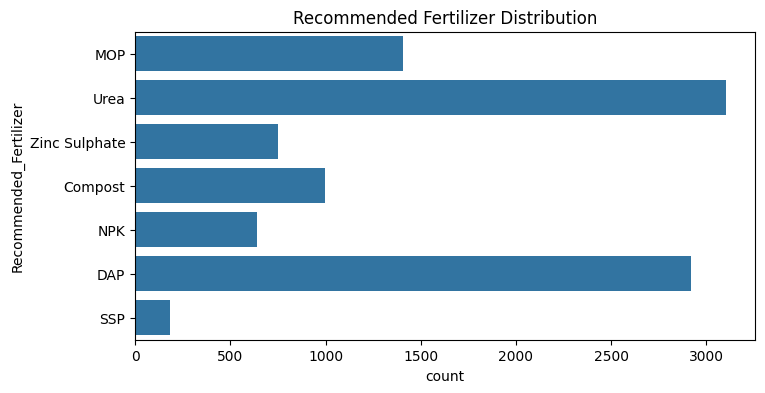

In [8]:
plt.figure(figsize=(8,4))
sns.countplot(y=df["Recommended_Fertilizer"])
plt.title("Recommended Fertilizer Distribution")
plt.show()


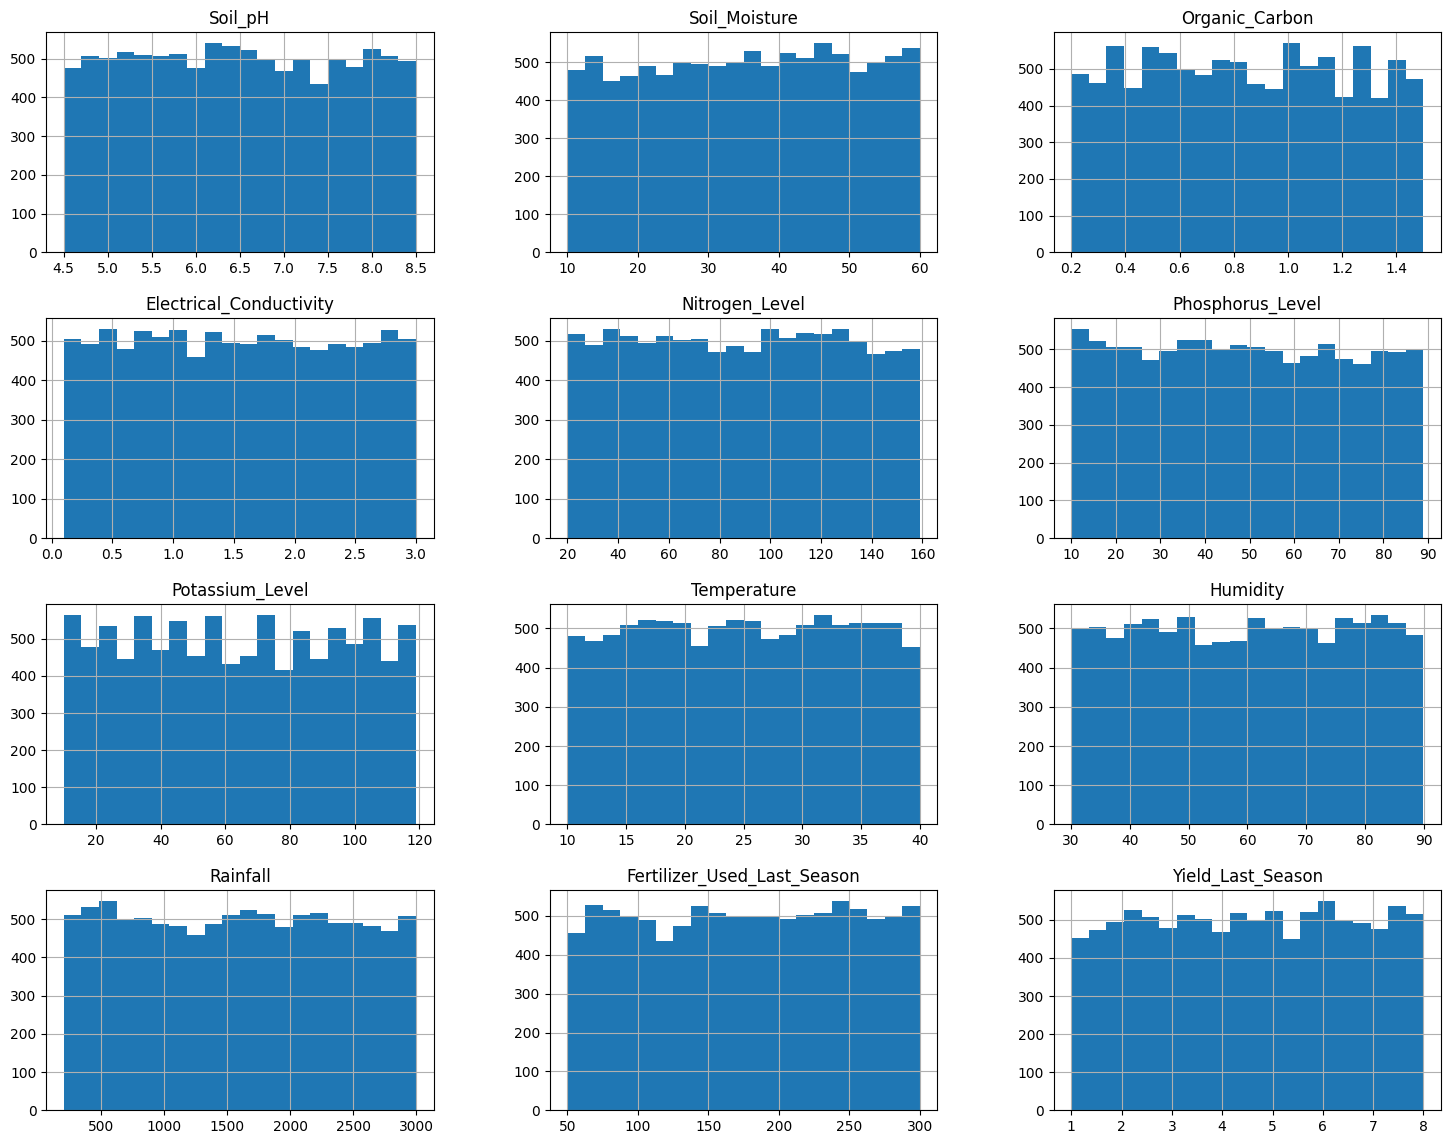

In [9]:
df[numerical_cols].hist(figsize=(18,14), bins=20)
plt.show()


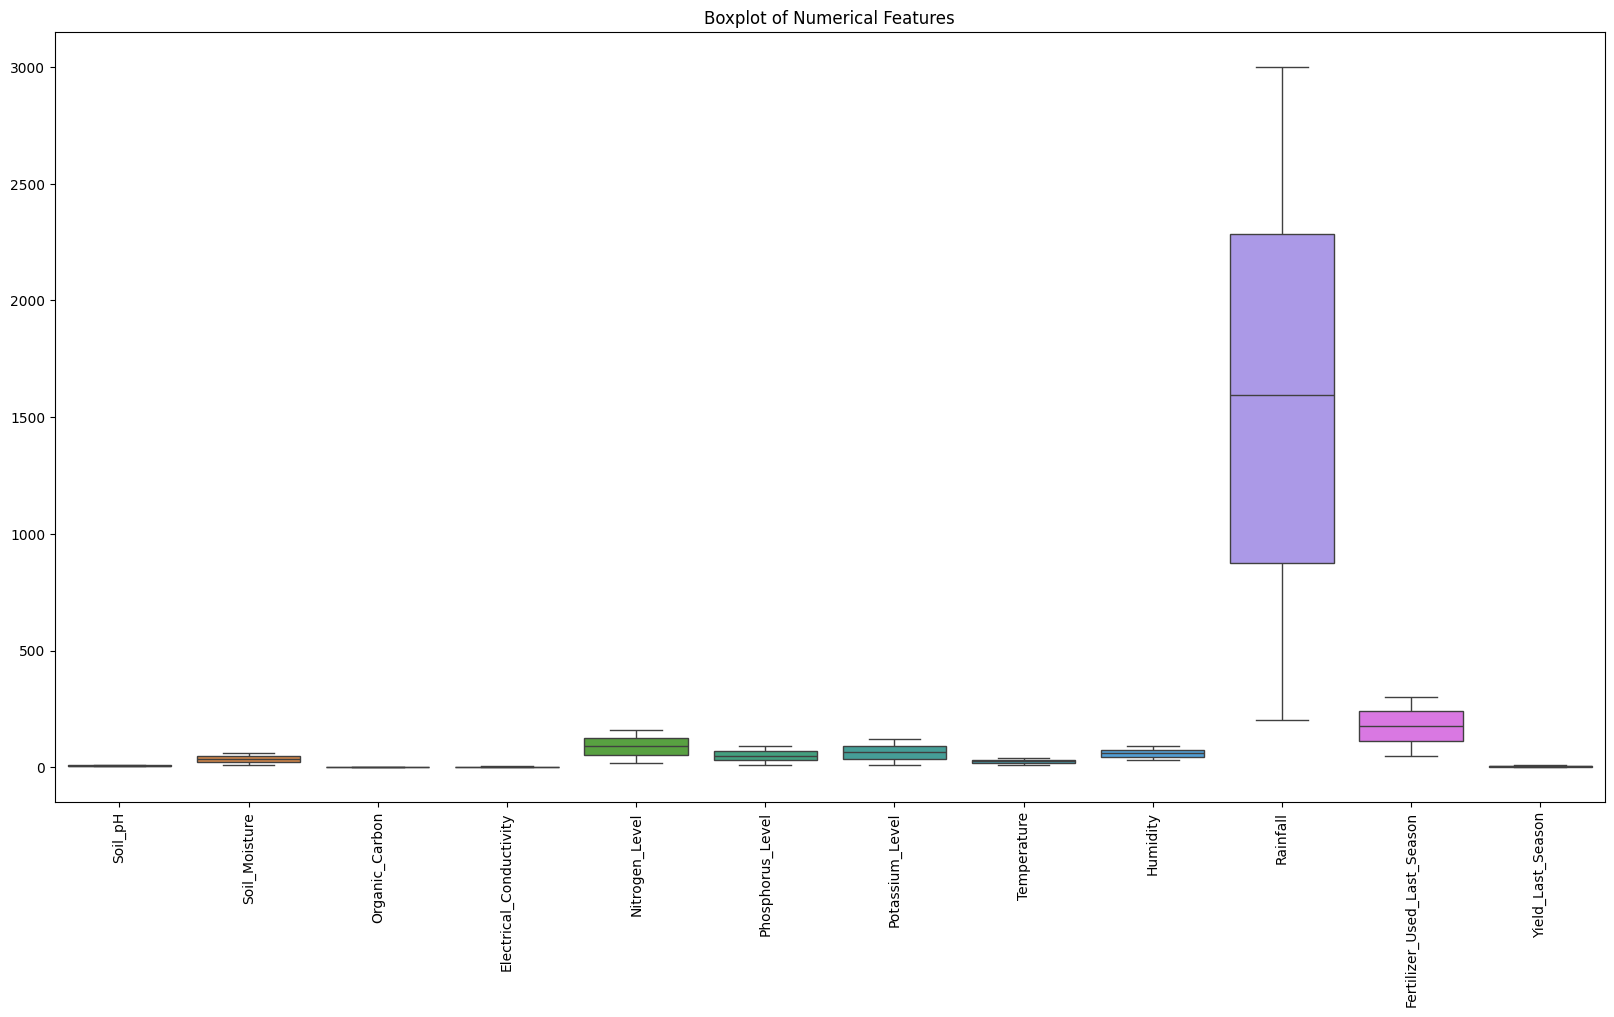

In [10]:
plt.figure(figsize=(20,10))
sns.boxplot(data=df[numerical_cols])
plt.xticks(rotation=90)
plt.title("Boxplot of Numerical Features")
plt.show()


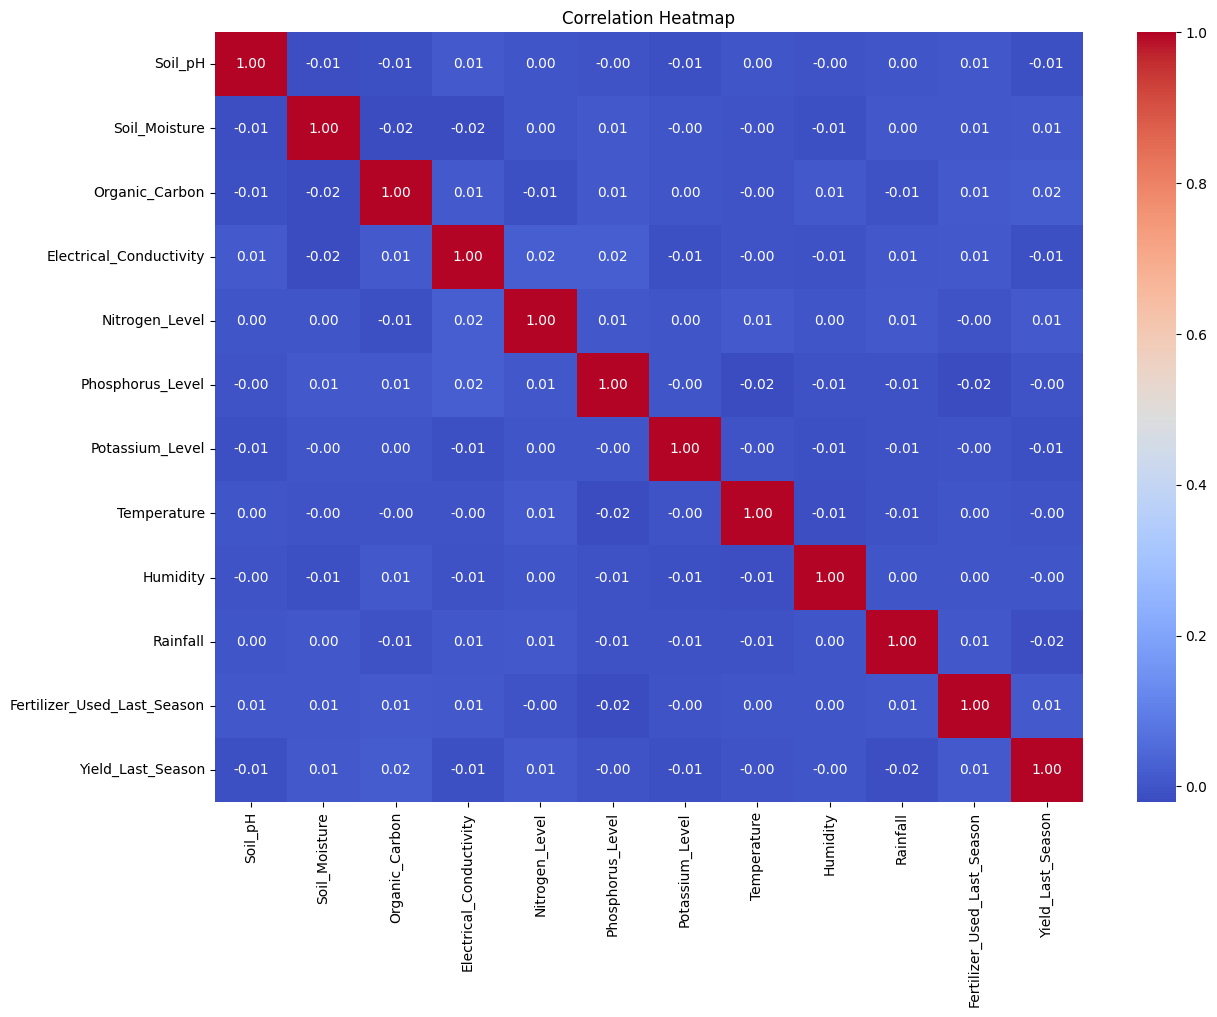

In [11]:
plt.figure(figsize=(14,10))
corr = df[numerical_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


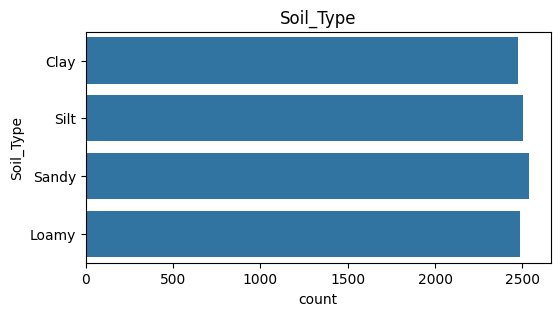

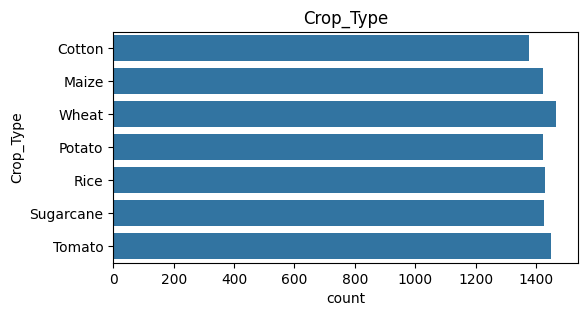

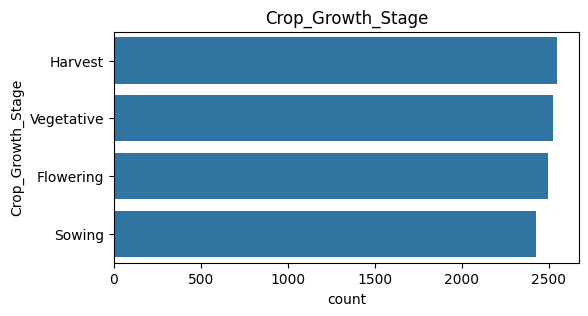

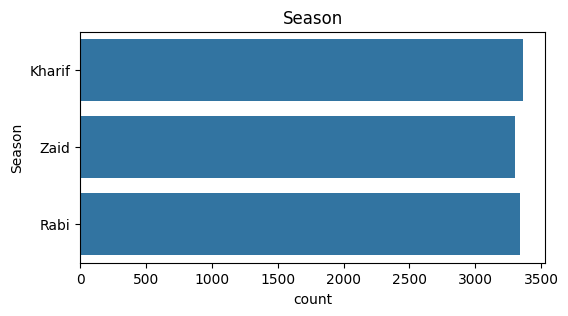

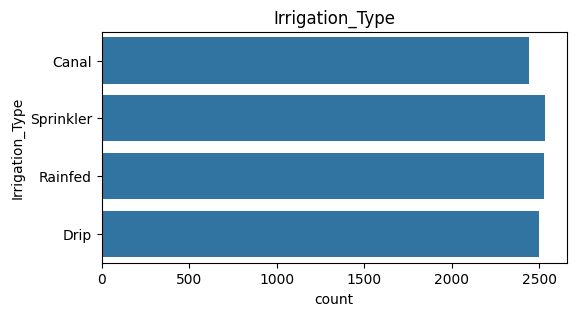

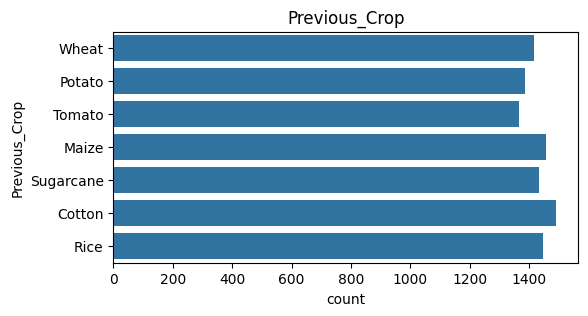

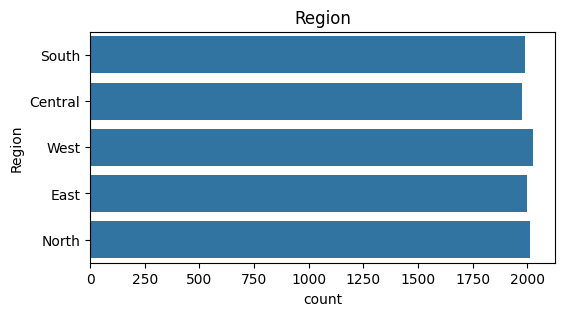

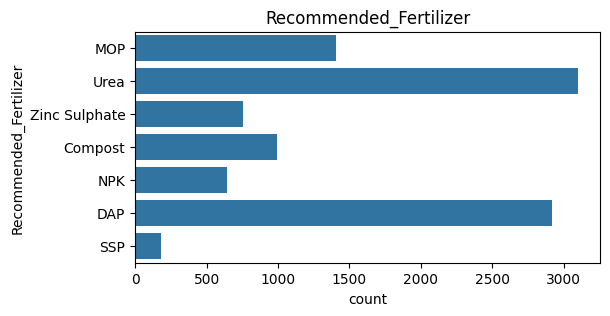

In [12]:
for col in categorical_cols:
    plt.figure(figsize=(6,3))
    sns.countplot(y=df[col])
    plt.title(col)
    plt.show()


In [13]:
le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])


In [14]:
X = df.drop(columns=["Recommended_Fertilizer"])
y = df["Recommended_Fertilizer"]


In [15]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)


In [17]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Extra Trees": ExtraTreesClassifier(),
    "Naive Bayes": GaussianNB(),
    "MLP Neural Network": MLPClassifier(max_iter=500)
}


In [18]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    
    results[name] = acc
    
    print("="*60)
    print(name)
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))


Logistic Regression
Accuracy: 0.788
              precision    recall  f1-score   support

           0       0.68      0.66      0.67       199
           1       0.83      0.89      0.86       584
           2       0.74      0.77      0.76       282
           3       0.77      0.44      0.56       128
           4       0.00      0.00      0.00        37
           5       0.83      0.90      0.87       620
           6       0.63      0.60      0.62       150

    accuracy                           0.79      2000
   macro avg       0.64      0.61      0.62      2000
weighted avg       0.77      0.79      0.78      2000

KNN
Accuracy: 0.5815
              precision    recall  f1-score   support

           0       0.37      0.42      0.39       199
           1       0.61      0.79      0.69       584
           2       0.52      0.47      0.49       282
           3       0.40      0.33      0.36       128
           4       0.00      0.00      0.00        37
           5       0.

In [19]:
results_df = pd.DataFrame({
    "Model": results.keys(),
    "Accuracy": results.values()
}).sort_values(by="Accuracy", ascending=False)

results_df


,Model,Accuracy
5,Gradient Boosting,0.8800
4,Random Forest,0.8755
3,Decision Tree,0.8730
6,AdaBoost,0.8730
9,MLP Neural Network,0.8490
7,Extra Trees,0.8330
8,Naive Bayes,0.7920
0,Logistic Regression,0.7880
2,SVM,0.7775
1,KNN,0.5815


In [20]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

importances = rf.feature_importances_
feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feature_importance_df


,Feature,Importance
5,Nitrogen_Level,0.354754
6,Phosphorus_Level,0.237215
7,Potassium_Level,0.102023
1,Soil_pH,0.100947
12,Crop_Growth_Stage,0.023318
9,Humidity,0.018014
2,Soil_Moisture,0.017542
17,Fertilizer_Used_Last_Season,0.017455
8,Temperature,0.017431
18,Yield_Last_Season,0.017415


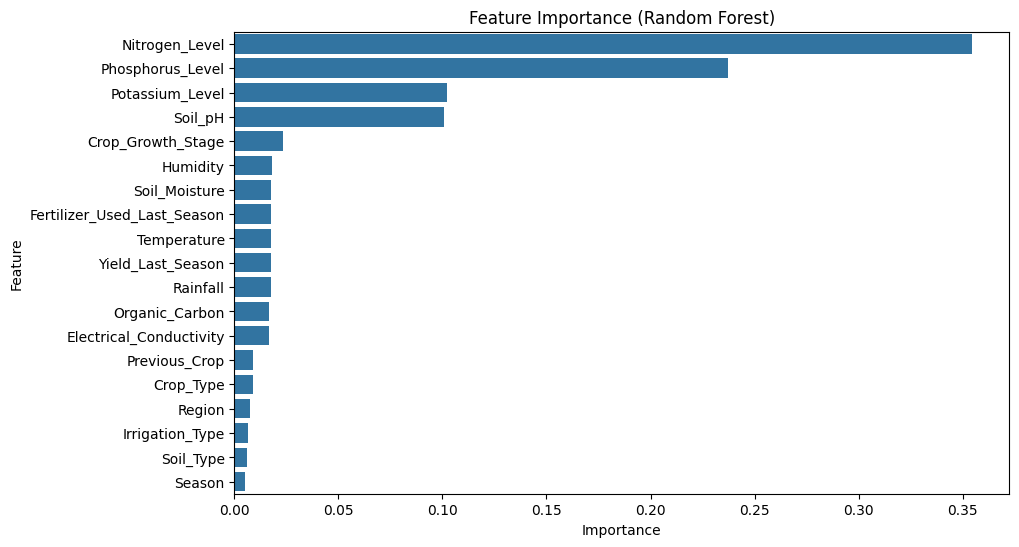

In [21]:
plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=feature_importance_df)
plt.title("Feature Importance (Random Forest)")
plt.show()
